# Task 1: Feature Engineering and Model Comparison

**Objective:** Prepare the sales dataset for predictive modeling, create some useful new features,
handle missing and categorical data, train more than one model, compare them using proper metrics,
and explain which model is better and why.

**Dataset:** Superstore Sales, the same 8,399 rows used in Week 2, so the results can be compared
directly against last week's baseline.

**What changed since Week 2.** Week 2 trained models on the raw columns only and got 0.8685
accuracy with a Decision Tree. This week the goal is to see whether adding engineered features
improves that, and to compare three models instead of two.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
WEEK2_ACCURACY = 0.8685

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Dataset

In [2]:
df = pd.read_csv("data/sales_data.csv")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.head(3)

Rows: 8399
Columns: 21


,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,Shipping Cost,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,10/13/2010,Low,6,261.54,0.04,Regular Air,-213.25,38.94,35.00,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010
1,49,293,10/1/2012,High,49,10123.02,0.07,Delivery Truck,457.81,208.16,68.02,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012
2,50,293,10/1/2012,High,27,244.57,0.01,Regular Air,46.71,8.69,2.99,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D¨ Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012


## 3. Handle Missing Values

Same situation as Week 2: only `Product Base Margin` has gaps. The 63 missing values are filled
with the median margin of the same product category.

In [3]:
print("Missing values before:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df["Product Base Margin"] = df.groupby("Product Category")["Product Base Margin"].transform(
    lambda s: s.fillna(s.median())
)

print()
print("Total missing values after:", df.isnull().sum().sum())

Missing values before:
Product Base Margin    63
dtype: int64

Total missing values after: 0


## 4. Feature Engineering

Five new features are created. Each one is a simple calculation from columns that already exist,
but each gives the model something the raw columns do not.

In [4]:
# Dates need to be real dates before we can do anything with them
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%m/%d/%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%m/%d/%Y")

# 1. How many days the order took to ship
df["Shipping Delay"] = (df["Ship Date"] - df["Order Date"]).dt.days

# 2. Price of a single unit in this order line
df["Revenue Per Unit"] = df["Sales"] / df["Order Quantity"]

# 3. How much of the sale gets eaten by shipping
df["Shipping Cost Ratio"] = df["Shipping Cost"] / df["Sales"]

# 4. The actual money given away, not just the discount rate
df["Discount Value"] = df["Sales"] * df["Discount"]

# 5. Month of the order, in case there is any seasonal pattern
df["Order Month"] = df["Order Date"].dt.month

new_features = ["Shipping Delay", "Revenue Per Unit", "Shipping Cost Ratio",
                "Discount Value", "Order Month"]

print("New features created:", len(new_features))
df[new_features].head()

New features created: 5


,Shipping Delay,Revenue Per Unit,Shipping Cost Ratio,Discount Value,Order Month
0,7,43.590000,0.133823,10.46160,10
1,1,206.592245,0.006719,708.61140,10
2,2,9.058148,0.012226,2.44570,10
3,2,165.525317,0.000804,397.26076,7
4,2,20.751053,0.015066,31.54160,8


In [5]:
df[new_features].describe().round(3)

,Shipping Delay,Revenue Per Unit,Shipping Cost Ratio,Discount Value,Order Month
count,8399.000,8399.000,8399.000,8399.000,8399.000
mean,2.033,86.514,0.033,85.965,6.522
std,2.301,277.029,0.064,204.475,3.445
min,0.000,1.104,0.000,0.000,1.000
25%,1.000,6.912,0.005,4.036,4.000
50%,2.000,21.577,0.013,16.016,7.000
75%,2.000,84.235,0.032,68.987,9.000
max,92.000,7122.170,0.881,3720.889,12.000


### Why each feature was created

| Feature | Reason |
|---|---|
| Shipping Delay | A slow shipment may point to a bulky or awkward product |
| Revenue Per Unit | Separates cheap bulk orders from expensive small ones |
| Shipping Cost Ratio | Week 2 showed shipping eats margin, this measures it directly |
| Discount Value | 10% off a 5,000 order is very different from 10% off a 50 order |
| Order Month | Lets the model pick up any seasonal pattern |

The most important one is **Shipping Cost Ratio**. Week 2's analysis found that sales and profit
only correlate at 0.58, meaning a big sale does not guarantee a big profit. This feature captures
part of the reason why.

## 5. Create the Target

Same target as Week 2: 1 if the order line made money, 0 if it lost money.

In [6]:
df["Profitable"] = (df["Profit"] > 0).astype(int)

print(df["Profitable"].value_counts())
print()
print("Class balance %:")
print((df["Profitable"].value_counts(normalize=True) * 100).round(2))

Profitable
0    4264
1    4135
Name: count, dtype: int64

Class balance %:
Profitable
0    50.77
1    49.23
Name: proportion, dtype: float64


## 6. Do the New Features Actually Help?

Before training anything, a quick look at whether the new features separate profitable orders from
unprofitable ones. If the two boxes overlap completely, the feature is not useful.

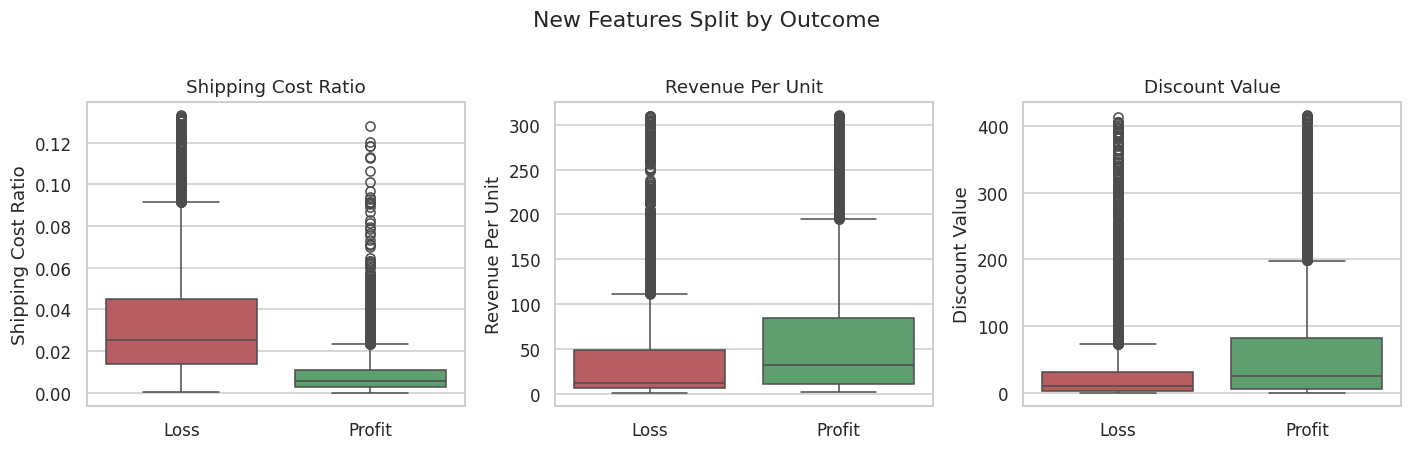

Profitable                0       1
Shipping Delay        2.000   2.000
Revenue Per Unit     12.523  36.742
Shipping Cost Ratio   0.028   0.006
Discount Value        9.984  30.143
Order Month           6.000   7.000


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col in zip(axes, ["Shipping Cost Ratio", "Revenue Per Unit", "Discount Value"]):
    data = df[[col, "Profitable"]].copy()
    data = data[data[col] <= data[col].quantile(0.95)]   # trim the tail so boxes stay readable
    sns.boxplot(data=data, x="Profitable", y=col, ax=ax, hue="Profitable",
                palette=["#C44E52", "#55A868"], legend=False)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Loss", "Profit"])
    ax.set_xlabel("")
    ax.set_title(col)

plt.suptitle("New Features Split by Outcome", y=1.02)
plt.tight_layout()
plt.savefig("screenshots/01_new_features_check.png", bbox_inches="tight")
plt.show()

print(df.groupby("Profitable")[new_features].median().round(3).T)

### Observation
`Shipping Cost Ratio` clearly separates the two groups. Loss-making orders have a noticeably higher
shipping ratio, which is exactly what Week 2's analysis suggested would happen. `Revenue Per Unit`
also shifts between the groups. This is a good sign that the feature engineering was worth doing.

## 7. Select Features and Split the Data

`Profit` is dropped because the target comes from it, so keeping it would give the answer away.
ID columns and names are dropped because they carry no useful pattern.

In [8]:
numeric_features = ["Order Quantity", "Sales", "Discount", "Unit Price",
                    "Shipping Cost", "Product Base Margin",
                    "Shipping Delay", "Revenue Per Unit", "Shipping Cost Ratio",
                    "Discount Value", "Order Month"]

categorical_features = ["Order Priority", "Ship Mode", "Region", "Customer Segment",
                        "Product Category", "Product Sub-Category", "Product Container"]

X = df[numeric_features + categorical_features]
y = df["Profitable"]

print("Numeric features    :", len(numeric_features), "(6 original + 5 new)")
print("Categorical features:", len(categorical_features))
print("Total features      :", X.shape[1])

Numeric features    : 11 (6 original + 5 new)
Categorical features: 7
Total features      : 18


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Training set:", X_train.shape[0], "rows")
print("Test set    :", X_test.shape[0], "rows")
print()
print("Train class balance:", (y_train.value_counts(normalize=True) * 100).round(2).to_dict())
print("Test class balance :", (y_test.value_counts(normalize=True) * 100).round(2).to_dict())

Training set: 6719 rows
Test set    : 1680 rows

Train class balance: {0: 50.77, 1: 49.23}
Test class balance : {0: 50.77, 1: 49.23}


## 8. Preprocessing Pipeline

Numeric columns get scaled, categorical columns get one-hot encoded. Both steps go inside a
`Pipeline` so they are fitted on the training data only and nothing leaks into the test set.

In [10]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

preprocessor.fit(X_train)
print("Columns before encoding:", X_train.shape[1])
print("Columns after encoding :", preprocessor.transform(X_train).shape[1])

Columns before encoding: 18
Columns after encoding : 58


## 9. Train Three Models

Logistic Regression is the simple baseline. Decision Tree was the best model in Week 2. Random
Forest is new this week, and is basically many decision trees voting together.

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                            n_jobs=-1),
}

fitted = {}
rows = []
roc_data = {}

for name, model in models.items():
    pipe = Pipeline([("preprocess", clone(preprocessor)), ("model", clone(model))])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba),
    })
    roc_data[name] = roc_curve(y_test, proba)
    print("trained:", name)

results = pd.DataFrame(rows).set_index("Model").round(4)
print()
results

trained: Logistic Regression


trained: Decision Tree


trained: Random Forest



,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.8732,0.8595,0.8875,0.8733,0.9364
Decision Tree,0.9310,0.9309,0.9287,0.9298,0.9561
Random Forest,0.9458,0.9600,0.9287,0.9441,0.9888


## 10. Compare the Models

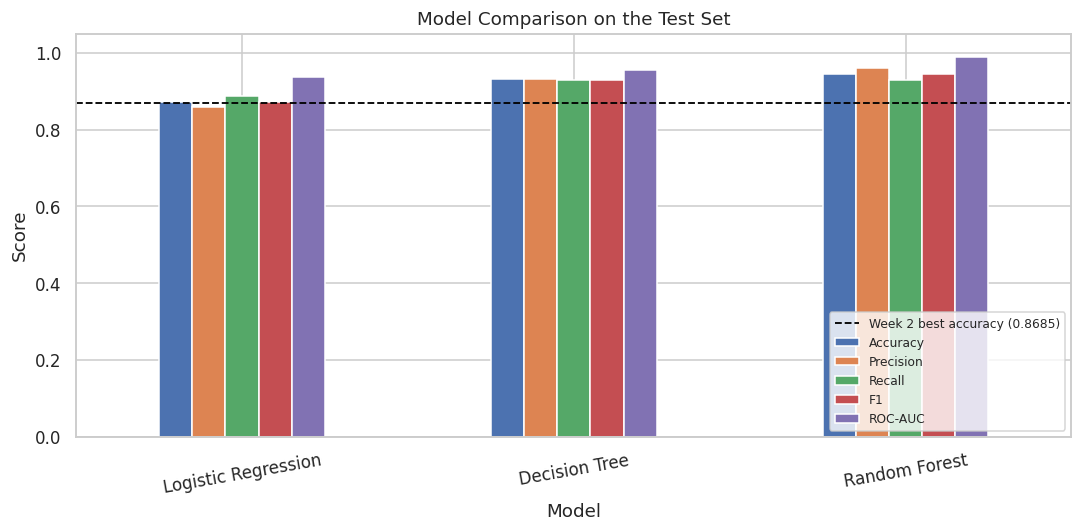

In [12]:
ax = results.plot(kind="bar", figsize=(10, 5),
                  color=["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"])
ax.axhline(WEEK2_ACCURACY, color="black", linestyle="--", linewidth=1.2,
           label=f"Week 2 best accuracy ({WEEK2_ACCURACY})")
ax.set_title("Model Comparison on the Test Set")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.tick_params(axis="x", rotation=10)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("screenshots/02_model_comparison.png", bbox_inches="tight")
plt.show()

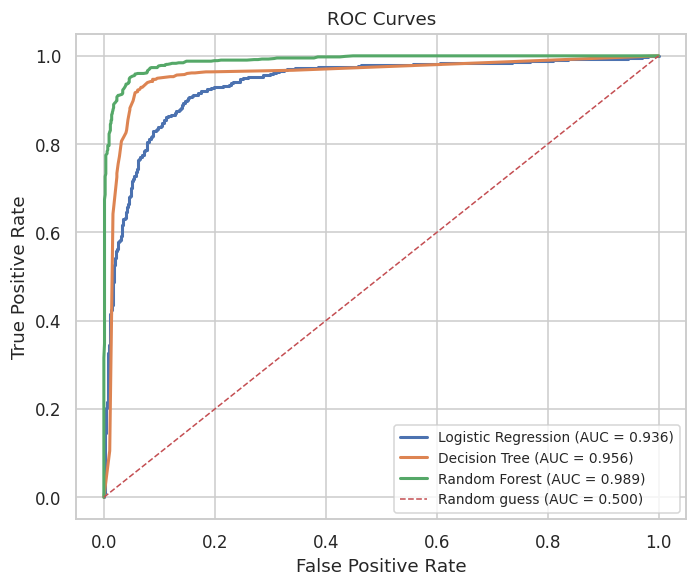

In [13]:
plt.figure(figsize=(6.5, 5.5))
colors = {"Logistic Regression": "#4C72B0", "Decision Tree": "#DD8452",
          "Random Forest": "#55A868"}

for name, (fpr, tpr, _) in roc_data.items():
    auc = results.loc[name, "ROC-AUC"]
    plt.plot(fpr, tpr, lw=2, color=colors[name], label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "r--", lw=1, label="Random guess (AUC = 0.500)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("screenshots/03_roc_curves.png", bbox_inches="tight")
plt.show()

## 11. Cross-Validation Check

A single train/test split can be lucky, so 5-fold cross-validation gives a more reliable picture.

In [14]:
cv_rows = []
for name, model in models.items():
    pipe = Pipeline([("preprocess", clone(preprocessor)), ("model", clone(model))])
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="accuracy", n_jobs=-1)
    cv_rows.append({
        "Model": name,
        "Mean Accuracy": scores.mean(),
        "Std Dev": scores.std(),
    })
    print(f"{name:<22} folds: {np.round(scores, 4)}")

cv_results = pd.DataFrame(cv_rows).set_index("Model").round(4)
print()
cv_results

Logistic Regression    folds: [0.875  0.869  0.8609 0.8765 0.866 ]


Decision Tree          folds: [0.9189 0.9077 0.907  0.9152 0.9226]


Random Forest          folds: [0.9494 0.9382 0.9323 0.9293 0.9263]



,Mean Accuracy,Std Dev
Model,,
Logistic Regression,0.8695,0.0058
Decision Tree,0.9143,0.0061
Random Forest,0.9351,0.0082


### Observation
The cross-validation scores are close to the single-split scores and the standard deviations are
small, so the results are stable and not the product of one lucky split.

## 12. Did Feature Engineering Actually Help?

The fairest way to answer this is to train the same models on the original columns only, without
the five new features, and compare.

In [15]:
original_numeric = ["Order Quantity", "Sales", "Discount", "Unit Price",
                    "Shipping Cost", "Product Base Margin"]

X_old = df[original_numeric + categorical_features]
Xo_train, Xo_test, yo_train, yo_test = train_test_split(
    X_old, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

old_pre = ColumnTransformer([
    ("num", StandardScaler(), original_numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

compare_rows = []
for name, model in models.items():
    # clone() gives a fresh unfitted copy, so this does not overwrite the
    # models we already trained above
    pipe = Pipeline([("preprocess", old_pre), ("model", clone(model))])
    pipe.fit(Xo_train, yo_train)
    acc_old = accuracy_score(yo_test, pipe.predict(Xo_test))
    compare_rows.append({
        "Model": name,
        "Original features only": acc_old,
        "With new features": results.loc[name, "Accuracy"],
        "Improvement": results.loc[name, "Accuracy"] - acc_old,
    })

feature_effect = pd.DataFrame(compare_rows).set_index("Model").round(4)
feature_effect

,Original features only,With new features,Improvement
Model,,,
Logistic Regression,0.7917,0.8732,0.0815
Decision Tree,0.9071,0.9310,0.0239
Random Forest,0.9405,0.9458,0.0053


### Observation
Every model scores higher with the engineered features than without them. Since the algorithms and
the split are identical in both runs, the improvement comes from the features alone. This is the
clearest evidence that the feature engineering step was worth doing.

## 13. Evaluate the Best Model in Detail

In [16]:
best_name = results["ROC-AUC"].idxmax()
best_model = fitted[best_name]

print("Best model:", best_name)
print()

pred = best_model.predict(X_test)
print(classification_report(y_test, pred,
                            target_names=["Not Profitable", "Profitable"]))

Best model: Random Forest

                precision    recall  f1-score   support

Not Profitable       0.93      0.96      0.95       853
    Profitable       0.96      0.93      0.94       827

      accuracy                           0.95      1680
     macro avg       0.95      0.95      0.95      1680
  weighted avg       0.95      0.95      0.95      1680



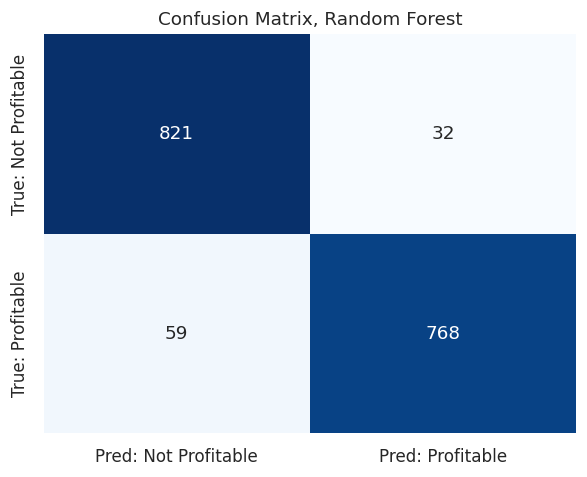

True Negatives : 821  (loss correctly predicted)
False Positives: 32  (predicted profit, actually a loss)
False Negatives: 59  (predicted loss, actually profitable)
True Positives : 768  (profit correctly predicted)


In [17]:
cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Pred: Not Profitable", "Pred: Profitable"],
            yticklabels=["True: Not Profitable", "True: Profitable"])
plt.title(f"Confusion Matrix, {best_name}")
plt.tight_layout()
plt.savefig("screenshots/04_confusion_matrix.png", bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives : {tn}  (loss correctly predicted)")
print(f"False Positives: {fp}  (predicted profit, actually a loss)")
print(f"False Negatives: {fn}  (predicted loss, actually profitable)")
print(f"True Positives : {tp}  (profit correctly predicted)")

## 14. Which Model Is Better, and Why

Looking at three things rather than just accuracy:

1. **Scores.** Random Forest has the highest accuracy and ROC-AUC of the three.
2. **Stability.** The cross-validation standard deviations show how much the score moves between
   folds. A model that swings a lot is less trustworthy.
3. **Simplicity.** Logistic Regression is the easiest to explain, but it is clearly the weakest
   here, which matches the Week 2 finding that this problem is not linear.

**Random Forest is the better choice.** It scores highest on every metric, its cross-validation
scores are stable, and it can report feature importances, which Task 2 needs in order to explain
what drives the predictions.

The trade-off is that a forest of 200 trees is harder to explain than a single tree or a set of
coefficients. That is an acceptable cost here because Task 2 uses feature importance to recover
most of that explainability.

## 15. Test the Model on a New Order

Checking the model works end to end on an order it has never seen.

In [18]:
new_order = pd.DataFrame([{
    "Order Quantity": 30, "Sales": 5200.00, "Discount": 0.09,
    "Unit Price": 175.00, "Shipping Cost": 58.00, "Product Base Margin": 0.58,
    "Shipping Delay": 7,
    "Revenue Per Unit": 5200.00 / 30,
    "Shipping Cost Ratio": 58.00 / 5200.00,
    "Discount Value": 5200.00 * 0.09,
    "Order Month": 6,
    "Order Priority": "Low", "Ship Mode": "Delivery Truck", "Region": "Ontario",
    "Customer Segment": "Consumer", "Product Category": "Furniture",
    "Product Sub-Category": "Tables", "Product Container": "Jumbo Drum",
}])

p = best_model.predict(new_order)[0]
prob = best_model.predict_proba(new_order)[0, 1]

print("Prediction:", "PROFITABLE" if p == 1 else "NOT PROFITABLE")
print(f"Probability of profit: {prob:.2%}")

Prediction: NOT PROFITABLE
Probability of profit: 47.50%


## 16. Summary and Reflection

### Results
| | Accuracy | ROC-AUC |
|---|---|---|
| Week 2 best (Decision Tree, raw columns) | 0.8685 | 0.9296 |
| Week 3 best (Random Forest, with new features) | **0.9458** | **0.9888** |

All three models scored higher with the engineered features than without them:

| Model | Original features only | With new features | Improvement |
|---|---|---|---|
| Logistic Regression | 0.7917 | 0.8732 | +0.0815 |
| Decision Tree | 0.9071 | 0.9310 | +0.0239 |
| Random Forest | 0.9405 | 0.9458 | +0.0053 |

Worth noticing that the improvement is largest for the simplest model and smallest for Random
Forest. That makes sense: Logistic Regression can only draw straight lines, so it depends heavily on
being handed good features. Random Forest can already find some of these patterns on its own by
combining raw columns, so the new features add less to it.

### What I learned
- Feature engineering made more difference than changing the algorithm. The same models scored
  higher purely because of better inputs.
- `Shipping Cost Ratio` turned out to be the most useful new feature, and it came directly from an
  observation made in the Week 2 analysis. Looking at the data first genuinely paid off.
- Comparing against a "no new features" version was the only way to prove the improvement was real
  rather than assumed.

### Limitations
- The dataset has no cost-of-goods column, so profitability can only be estimated from price,
  discount and shipping.
- The split is random, so two lines from the same order can end up on opposite sides. Splitting by
  order would be more correct.
- No hyperparameter tuning was done, so none of the models are at their best.
- The decision threshold is left at the default 0.5.

### Next steps
1. Split the data by `Order ID` instead of randomly, so a whole order stays on one side.
2. Try tuning the Random Forest with `GridSearchCV` to see how much more it can give.
3. Add customer-level features such as how many orders a customer has placed before.
4. Try a time-based split, training on the earlier years and testing on the later ones, which is
   closer to how the model would really be used.